### Importing Libraries

This cell imports all the necessary Python libraries that will be used throughout the analysis and modeling process. Each library serves a specific purpose:


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
from prophet import Prophet
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import xgboost as xgb

### Loading and Initial Data Inspection

This cell loads the retail sales data from a CSV file named `retail_sales.csv` into a pandas DataFrame called `df`. It then displays the first 10 rows of the DataFrame using `df.head(10)` to give a quick overview of the data's structure and content.

In [ ]:
df = pd.read_csv('retail_sales.csv')
print(df.head(10))

         date store_id item_id  sales  price  promo  weekday  month
0  2019-01-01  store_1  item_1     41  21.30      0        1      1
1  2019-01-02  store_1  item_1     53  21.30      0        2      1
2  2019-01-03  store_1  item_1     39  21.30      0        3      1
3  2019-01-04  store_1  item_1     35  21.30      0        4      1
4  2019-01-05  store_1  item_1     51  17.04      1        5      1
5  2019-01-06  store_1  item_1     38  21.30      0        6      1
6  2019-01-07  store_1  item_1     45  21.30      0        0      1
7  2019-01-08  store_1  item_1     48  21.30      0        1      1
8  2019-01-09  store_1  item_1     50  21.30      0        2      1
9  2019-01-10  store_1  item_1     44  21.30      0        3      1


### Date-based Feature Engineering

These cells process the 'date' column to extract additional time-based features that can be useful for forecasting models. This is a common step in time series analysis to provide models with more context about the time of year or day.



In [ ]:
# Ensure 'date' is a datetime object
df['date'] = pd.to_datetime(df['date'])

# Extract time-based features
df['year'] = df['date'].dt.year
#df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
#df['dayofweek'] = df['date'].dt.dayofweek
df['dayofyear'] = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

In [ ]:
df.head(10)

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,dayofyear,weekofyear
0,2019-01-01,store_1,item_1,41,21.30,0,1,1,2019,1,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1,2019,2,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1,2019,3,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1,2019,4,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1,2019,5,5,1
5,2019-01-06,store_1,item_1,38,21.30,0,6,1,2019,6,6,1
6,2019-01-07,store_1,item_1,45,21.30,0,0,1,2019,7,7,2
7,2019-01-08,store_1,item_1,48,21.30,0,1,1,2019,8,8,2
8,2019-01-09,store_1,item_1,50,21.30,0,2,1,2019,9,9,2
9,2019-01-10,store_1,item_1,44,21.30,0,3,1,2019,10,10,2


### Label Encoding Categorical Features

These cells prepare categorical (text-based) features for machine learning models by converting them into numerical representations. Many machine learning algorithms require numerical input.


In [ ]:
label_encoder = LabelEncoder()

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = label_encoder.fit_transform(df[col])
    print(f"Column '{col}' label encoded successfully.")
  else:
    print(f"Column '{col}' is not of object datatype, skipping.")
display(df.head())
display(df.info())

Column 'date' is not of object datatype, skipping.
Column 'store_id' label encoded successfully.
Column 'item_id' label encoded successfully.
Column 'sales' is not of object datatype, skipping.
Column 'price' is not of object datatype, skipping.
Column 'promo' is not of object datatype, skipping.
Column 'weekday' is not of object datatype, skipping.
Column 'month' is not of object datatype, skipping.
Column 'year' is not of object datatype, skipping.
Column 'day' is not of object datatype, skipping.
Column 'dayofyear' is not of object datatype, skipping.
Column 'weekofyear' is not of object datatype, skipping.


,date,store_id,item_id,sales,price,promo,weekday,month,year,day,dayofyear,weekofyear
0,2019-01-01,0,0,41,21.30,0,1,1,2019,1,1,1
1,2019-01-02,0,0,53,21.30,0,2,1,2019,2,2,1
2,2019-01-03,0,0,39,21.30,0,3,1,2019,3,3,1
3,2019-01-04,0,0,35,21.30,0,4,1,2019,4,4,1
4,2019-01-05,0,0,51,17.04,1,5,1,2019,5,5,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 12 columns):
 #   Column      Dtype         
---  ------      -----         
 0   date        datetime64[ns]
 1   store_id    int64         
 2   item_id     int64         
 3   sales       int64         
 4   price       float64       
 5   promo       int64         
 6   weekday     int64         
 7   month       int64         
 8   year        int32         
 9   day         int32         
 10  dayofyear   int32         
 11  weekofyear  int64         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(7)
memory usage: 365.7 MB


None

### Visualizing Total Sales Over Time (Cell `e91a3260`)

This cell aggregates the daily sales data and then visualizes the trend of total sales over the entire period in the dataset.

1.  **`daily_sales = df.groupby('date')['sales'].sum().reset_index()`**: Groups the DataFrame by 'date' and calculates the sum of 'sales' for each day, creating a new DataFrame `daily_sales`.
2.  **`fig = px.line(...)`**: Uses `plotly.express` to create an interactive line plot, with 'date' on the x-axis and 'sales' on the y-axis, showing the overall sales trend.

In [ ]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()

fig = px.line(daily_sales, x='date', y='sales', title='Total Sales Over Time')
fig.show()

### Promotion Impact Analysis (Cells `Xe3yDT7X3Pgs` and `208f3f00`)

These cells analyze the average sales during promotional periods versus non-promotional periods to understand the impact of promotions.

1.  **`sales_without_promo = df[df['promo']==0]['sales'].mean()`**: Calculates the average sales when `promo` (promotion status) is 0 (no promotion).
2.  **`sales_by_promo = df[df['promo']==1]['sales'].mean()`**: Calculates the average sales when `promo` is 1 (promotion active).
3.  A bar chart is then created using `plotly.graph_objects` to visually compare these two average sales figures, making it clear how promotions affect sales.

In [ ]:
sales_without_promo = df[df['promo']==0]['sales'].mean()
sales_by_promo = df[df['promo']==1]['sales'].mean()
print(sales_without_promo)
print(sales_by_promo)

27.86482775003858
41.8633366484554


In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=['No Promotion'],
    y=[sales_without_promo],
    name='No Promotion',
    text=[f'{sales_without_promo:.2f}'],
    textposition='auto'
))

fig.add_trace(go.Bar(
    x=['With Promotion'],
    y=[sales_by_promo],
    name='With Promotion',
    text=[f'{sales_by_promo:.2f}'],
    textposition='auto'
))

fig.update_layout(
    title='Average Sales: Promotion vs. No Promotion',
    xaxis_title='Promotion Status',
    yaxis_title='Average Sales',
    barmode='group'
)

fig.show()

### Preparing Data for Prophet (Cell `2cec33bf`)

This cell aggregates the data to a daily level, which is the required format for the Prophet forecasting library. It also includes the 'promo' information as an additional regressor.

1.  **`prophet_df = df.groupby('date').agg({'sales': 'sum', 'promo': 'mean'}).reset_index()`**: Groups the original DataFrame `df` by 'date', sums the 'sales', and takes the mean of 'promo' (since 'promo' is binary, the mean represents the proportion of items on promo that day).
2.  **`prophet_df = prophet_df.rename(columns={'date': 'ds', 'sales': 'y'})`**: Renames the 'date' column to 'ds' (datestamp) and 'sales' to 'y' (target variable), as required by Prophet.

In [ ]:
prophet_df = df.groupby('date').agg({'sales': 'sum', 'promo': 'mean'}).reset_index()
prophet_df = prophet_df.rename(columns={'date': 'ds', 'sales': 'y'})

print(prophet_df.head())
print(prophet_df.info())

          ds      y   promo
0 2019-01-01  74119  0.1004
1 2019-01-02  77119  0.0976
2 2019-01-03  70810  0.1080
3 2019-01-04  59269  0.0932
4 2019-01-05  52621  0.1028
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1826 non-null   datetime64[ns]
 1   y       1826 non-null   int64         
 2   promo   1826 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 42.9 KB
None


### Prophet Model Training and Forecasting (Cell `c80b679f`)

This cell initializes, trains, and uses the Prophet model to forecast future sales.

1.  **`model = Prophet(daily_seasonality=True)`**: Initializes the Prophet model. `daily_seasonality=True` tells the model to look for daily patterns in sales.
2.  **`model.add_regressor('promo')`**: Adds the 'promo' column as an external regressor, allowing Prophet to account for its impact on sales.
3.  **`model.fit(prophet_df)`**: Trains the Prophet model using the prepared historical data.
4.  **`future = model.make_future_dataframe(periods=90, include_history=False)`**: Creates a DataFrame `future` containing dates for the next 90 days for which we want to make predictions.
5.  **`future['promo'] = mean_promo`**: Since we don't know future promotions, the average promotion rate from historical data (`mean_promo`) is used for future predictions.
6.  **`forecast = model.predict(future)`**: Generates sales forecasts for the future dates in the `future` DataFrame.

In [ ]:
model = Prophet(daily_seasonality=True)
model.add_regressor('promo')
model.fit(prophet_df)

future = model.make_future_dataframe(periods=90, include_history=False)
mean_promo = prophet_df['promo'].mean()
future['promo'] = mean_promo

forecast = model.predict(future)
display(forecast.head())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-01,90835.736011,78651.097890,84587.442660,90835.736011,90835.736011,-9106.640531,-9106.640531,-9106.640531,-9245.003052,...,-17.127980,-17.127980,-17.127980,155.490502,155.490502,155.490502,0.0,0.0,0.0,81729.095480
1,2024-01-02,90840.857913,90674.350035,96623.853263,90840.857913,90840.857913,2726.016499,2726.016499,2726.016499,-9245.003052,...,11425.810804,11425.810804,11425.810804,545.208747,545.208747,545.208747,0.0,0.0,0.0,93566.874411
2,2024-01-03,90845.979814,93888.345073,99987.442862,90845.979814,90845.979814,5970.382045,5970.382045,5970.382045,-9245.003052,...,14280.384758,14280.384758,14280.384758,935.000340,935.000340,935.000340,0.0,0.0,0.0,96816.361859
3,2024-01-04,90851.101715,86301.389188,92168.489415,90851.101715,90851.101715,-1558.228021,-1558.228021,-1558.228021,-9245.003052,...,6362.097658,6362.097658,6362.097658,1324.677374,1324.677374,1324.677374,0.0,0.0,0.0,89292.873695
4,2024-01-05,90856.223617,73808.023774,79759.837848,90856.223617,90856.223617,-13880.870172,-13880.870172,-13880.870172,-9245.003052,...,-6349.907990,-6349.907990,-6349.907990,1714.040870,1714.040870,1714.040870,0.0,0.0,0.0,76975.353444


### Visualizing Prophet Forecast and Components (Cells `90891e0c` and `299d6ced`)

These cells display the results of the Prophet forecast in graphical form.

1.  **`fig = model.plot(forecast)`**: Plots the actual historical sales, the forecasted sales, and the uncertainty intervals for the forecast.
2.  **`fig_components = model.plot_components(forecast)`**: This plot breaks down the forecast into its individual components: the overall trend, yearly seasonality, weekly seasonality, daily seasonality, and the impact of the 'promo' regressor. This helps in understanding the underlying patterns Prophet has identified.

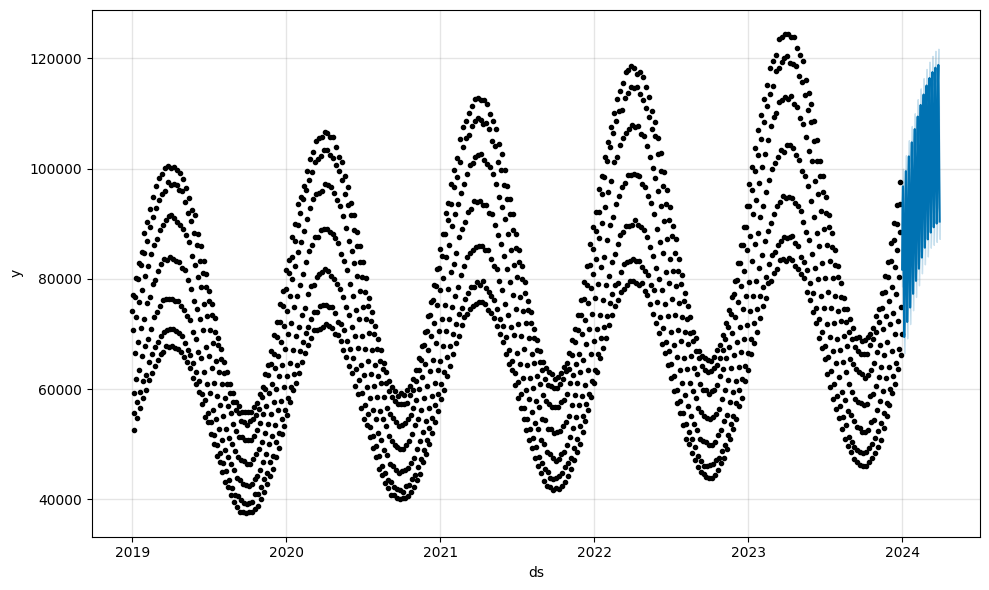

In [ ]:
fig = model.plot(forecast)
fig.show()

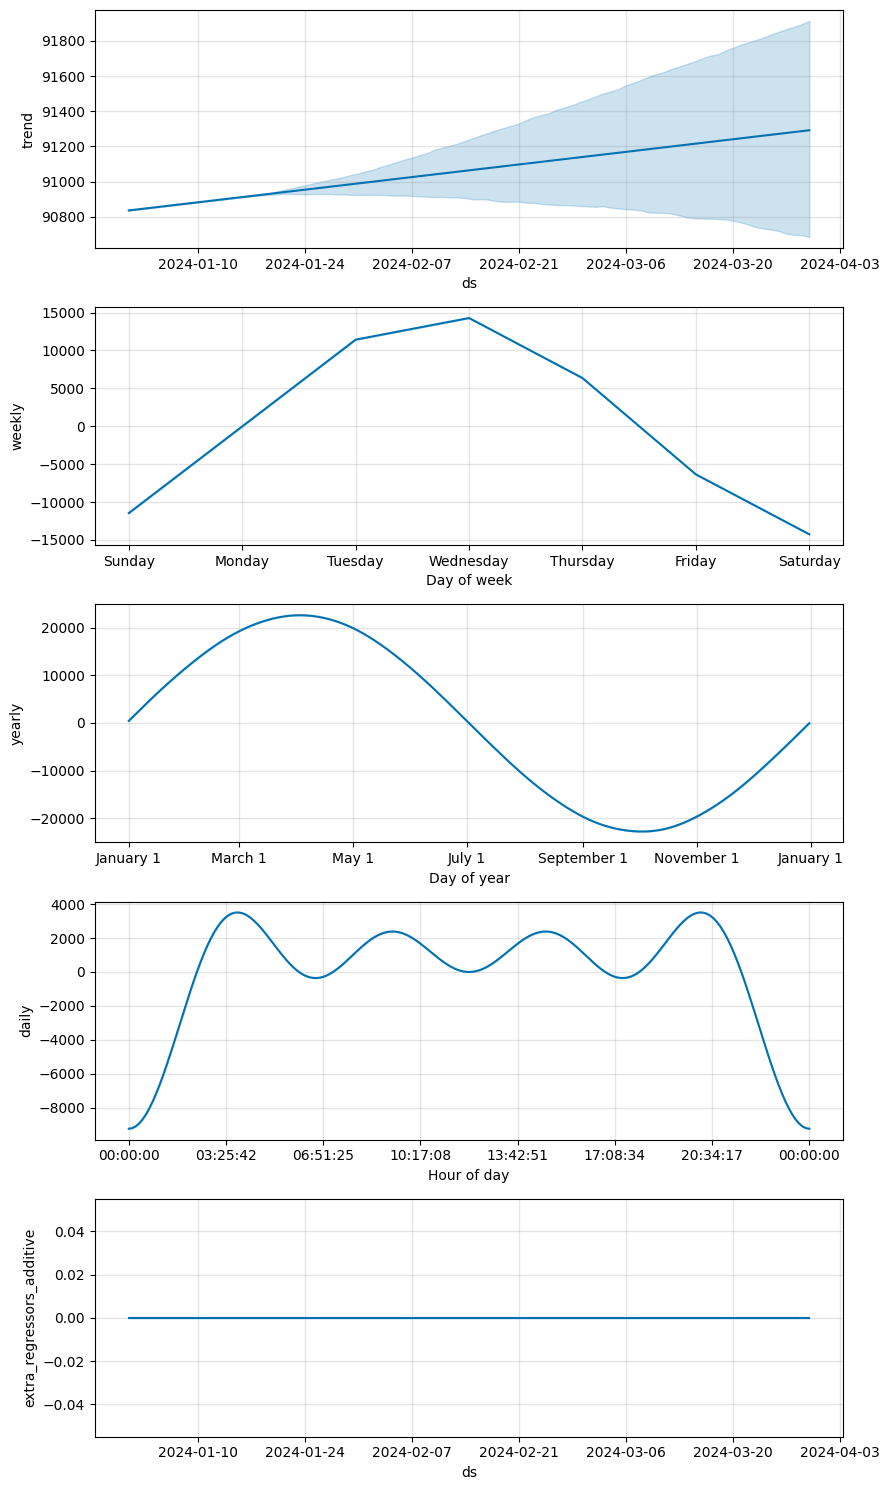

In [ ]:
fig_components = model.plot_components(forecast)
fig_components.show()


### Evaluating Prophet Model Performance

This section evaluates how well the Prophet model performs on unseen data by splitting the historical data into training and testing sets.



In [ ]:
train = prophet_df[:-90]
test = prophet_df[-90:]

model_eval = Prophet(daily_seasonality=True)
model_eval.add_regressor('promo')
model_eval.fit(train)

future_eval = model_eval.make_future_dataframe(periods=len(test), include_history=False)
future_eval['promo'] = train['promo'].mean() # Using mean from training data

forecast_eval = model_eval.predict(future_eval)

mae = mean_absolute_error(test['y'], forecast_eval['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_eval['yhat']))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 1473.64
Root Mean Squared Error (RMSE): 1967.66


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

train = prophet_df[:-90]
test = prophet_df[-90:]

model_eval = Prophet(daily_seasonality=True)
model_eval.add_regressor('promo')
model_eval.fit(train)

future_eval = model_eval.make_future_dataframe(periods=len(test), include_history=False)
future_eval['promo'] = train['promo'].mean() # Using mean from training data

forecast_eval = model_eval.predict(future_eval)

mae = mean_absolute_error(test['y'], forecast_eval['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_eval['yhat']))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 1473.64
Root Mean Squared Error (RMSE): 1967.66


### Advanced Feature Engineering for Other Models

This cell adds more sophisticated features to the `prophet_df` (which is already aggregated daily) to potentially improve the performance of other machine learning models like XGBoost.



In [ ]:
prophet_df['y_lag_1'] = prophet_df['y'].shift(1)
prophet_df['y_lag_7'] = prophet_df['y'].shift(7)
prophet_df['y_lag_30'] = prophet_df['y'].shift(30)

prophet_df['y_rolling_mean_7'] = prophet_df['y'].rolling(window=7).mean()

prophet_df = prophet_df.fillna(0)

display(prophet_df.head())
display(prophet_df.tail())

,ds,y,promo,y_lag_1,y_lag_7,y_lag_30,y_rolling_mean_7
0,2019-01-01,74119,0.1004,0.0,0.0,0.0,0.0
1,2019-01-02,77119,0.0976,74119.0,0.0,0.0,0.0
2,2019-01-03,70810,0.1080,77119.0,0.0,0.0,0.0
3,2019-01-04,59269,0.0932,70810.0,0.0,0.0,0.0
4,2019-01-05,52621,0.1028,59269.0,0.0,0.0,0.0


,ds,y,promo,y_lag_1,y_lag_7,y_lag_30,y_rolling_mean_7
1821,2023-12-27,97603,0.1100,93568.0,93491.0,68539.0,80032.142857
1822,2023-12-28,88506,0.0944,97603.0,85338.0,80274.0,80484.714286
1823,2023-12-29,74957,0.0992,88506.0,72341.0,83050.0,80858.428571
1824,2023-12-30,66218,0.0976,74957.0,63737.0,76011.0,81212.857143
1825,2023-12-31,70053,0.0980,66218.0,67263.0,64028.0,81611.428571


### XGBoost Regressor Model

This cell builds and evaluates an XGBoost (Extreme Gradient Boosting) model, which is a powerful ensemble machine learning algorithm known for its performance.



In [ ]:
xgb_df = prophet_df.copy()
# Add time-based features from the original df by merging on date
# Assuming df contains 'date', 'year', 'month', 'day', 'weekday', 'dayofyear', 'weekofyear'
# I'll need to make sure these columns are in xgb_df, if not, re-extract them from 'ds'

xgb_df['year'] = xgb_df['ds'].dt.year
xgb_df['month'] = xgb_df['ds'].dt.month
xgb_df['day'] = xgb_df['ds'].dt.day
xgb_df['weekday'] = xgb_df['ds'].dt.dayofweek # Using dayofweek as per original df['weekday'] column
xgb_df['dayofyear'] = xgb_df['ds'].dt.dayofyear
xgb_df['weekofyear'] = xgb_df['ds'].dt.isocalendar().week.astype(int)

# Define features and target
features = ['promo', 'y_lag_1', 'y_lag_7', 'y_lag_30', 'y_rolling_mean_7',
            'year', 'month', 'day', 'weekday', 'dayofyear', 'weekofyear']
target = 'y'

X = xgb_df[features]
y = xgb_df[target]

# Split data into training and testing sets (last 90 days for test)
X_train = X[:-90]
X_test = X[-90:]
y_train = y[:-90]
y_test = y[-90:]

# Initialize and train XGBoost Regressor
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=42)
model_xgb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = model_xgb.predict(X_test)

# Calculate MAE and RMSE
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f'XGBoost Mean Absolute Error (MAE): {mae_xgb:.2f}')
print(f'XGBoost Root Mean Squared Error (RMSE): {rmse_xgb:.2f}')

XGBoost Mean Absolute Error (MAE): 573.89
XGBoost Root Mean Squared Error (RMSE): 865.05


### SARIMA Model

This cell implements and evaluates a Seasonal AutoRegressive Integrated Moving Average (SARIMA) model, another traditional time series forecasting method.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare data for SARIMA - use the 'y' column (total sales)
sarima_data = prophet_df[['ds', 'y']].set_index('ds')

# Split data into training and testing sets (last 90 days for test)
sarima_train = sarima_data[:-90]
sarima_test = sarima_data[-90:]

# Initialize and train SARIMA model
# Using seasonal order (1,1,1,7) for weekly seasonality, common for daily data
# Non-seasonal order (1,1,1) is a common starting point
model_sarima = SARIMAX(sarima_train['y'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# Fit the model
sarima_results = model_sarima.fit(disp=False)

# Make predictions on the test set
sarima_pred = sarima_results.predict(start=len(sarima_train), end=len(sarima_data)-1)

# Calculate MAE and RMSE
mae_sarima = mean_absolute_error(sarima_test['y'], sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(sarima_test['y'], sarima_pred))

print(f'SARIMA Mean Absolute Error (MAE): {mae_sarima:.2f}')
print(f'SARIMA Root Mean Squared Error (RMSE): {rmse_sarima:.2f}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



SARIMA Mean Absolute Error (MAE): 12155.94
SARIMA Root Mean Squared Error (RMSE): 15348.37


### Model Comparison and Summary

These cells bring together the evaluation metrics from all three models to compare their performance and conclude which model is best suited for the task.



In [ ]:
results = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost', 'SARIMA'],
    'MAE': [mae, mae_xgb, mae_sarima],
    'RMSE': [rmse, rmse_xgb, rmse_sarima]
})

results = results.round(2)

print("\nModel Comparison:")
display(results)


Model Comparison:


,Model,MAE,RMSE
0,Prophet,1473.64,1967.66
1,XGBoost,573.89,865.05
2,SARIMA,12155.94,15348.37


## Summarize Findings and Recommend Best Forecasting Approach

Based on the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) metrics, we can assess the performance of each model:

*   **XGBoost Regressor**: Achieved the lowest MAE (573.89) and RMSE (865.05), indicating superior performance in predicting sales compared to Prophet and SARIMA.
*   **Prophet**: Performed reasonably well with an MAE of 1473.64 and RMSE of 1967.66.
*   **SARIMA**: Showed the highest errors with an MAE of 12155.94 and RMSE of 15348.37.

**Recommendation**: The **XGBoost Regressor** is the recommended forecasting approach for future sales predictions. Its ability to incorporate advanced features like lag values and rolling means, combined with its robust tree-based learning, resulted in significantly better accuracy metrics on the test set. While Prophet offers interpretability with its trend, seasonality, and holiday components, XGBoost's predictive power, especially with engineered features, makes it a more suitable choice for this dataset.